# Task 6: House Price Prediction
## Goal: To predict house prices based on features like income, age, and rooms using Linear Regression.
## Data Preprocessing: We removed the 'Address' column and scaled features using StandardScaler to ensure the model treats all inputs fairly.
## Results: The model achieved an MAE of $80,879 and an Error Percentage of 6.51%, indicating high accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
import pandas as pd

# Load the file we just uploaded
df = pd.read_csv('USA_Housing.csv')

# Look at the first 5 rows to make sure it's correct
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [6]:
# 1. Check for missing values (NaN)
print("Missing values in each column:")
print(df.isnull().sum())

# 2. Remove the 'Address' column because it's unique text
# 'axis=1' means we are dropping a column, not a row
df_clean = df.drop('Address', axis=1)

# 3. See the new "Clean" table
df_clean.head()

Missing values in each column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [7]:
# 1. Define X (everything except Price) and y (only Price)
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

# 2. Split the data
# test_size=0.2 means 80% for training and 20% for testing
# random_state=42 ensures we get the same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Check the shapes to see the split
print(f"Total rows in dataset: {len(df_clean)}")
print(f"Rows for Training (80%): {len(X_train)}")
print(f"Rows for Testing (20%): {len(X_test)}")

Total rows in dataset: 5000
Rows for Training (80%): 4000
Rows for Testing (20%): 1000


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. "Fit" and "Transform" the Training data
# This calculates the average and scales the 4,000 rows
X_train_scaled = scaler.fit_transform(X_train)

# 3. "Transform" the Test data
# We ONLY transform (not fit) the test data to keep the "exam" fair
X_test_scaled = scaler.transform(X_test)

# 4. Look at one row to see the change
print("First row of original data (Income, Age, etc.):")
print(X_train.iloc[0].values)

print("\nFirst row of SCALED data (Notice they are now small numbers):")
print(X_train_scaled[0])

First row of original data (Income, Age, etc.):
[6.65470165e+04 5.84609530e+00 6.84729811e+00 4.13000000e+00
 2.78508229e+04]

First row of SCALED data (Notice they are now small numbers):
[-0.19049241 -0.12817719 -0.13160635  0.12038585 -0.82761782]


In [9]:
from sklearn.linear_model import LinearRegression

# 1. Initialize the model (The "Brain")
model = LinearRegression()

# 2. Train the model (The "Learning" Step)
# We give it the SCALED features and the REAL prices
model.fit(X_train_scaled, y_train)

# 3. Make Predictions
# Now we ask the AI to "guess" the prices for our 1,000 test houses
predictions = model.predict(X_test_scaled)

print("Training Complete!")
print(f"First 5 Predicted Prices: {predictions[:5]}")
print(f"First 5 Actual Prices:    {y_test.values[:5]}")

Training Complete!
First 5 Predicted Prices: [1308587.92699753 1237037.22949428 1243429.34030687 1228900.21360379
 1063320.9071082 ]
First 5 Actual Prices:    [1339096.07724513 1251794.17883686 1340094.96620542 1431507.62342797
 1042373.52409608]


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Calculate MAE
mae = mean_absolute_error(y_test, predictions)

# 2. Calculate RMSE
# We take the square root of MSE to get it back into "dollars"
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# 3. Print the results
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# 4. Check the average house price to see if the error is "good" or "bad"
avg_price = y_test.mean()
print(f"\nAverage House Price in Test Set: ${avg_price:,.2f}")
print(f"Error Percentage: {(mae/avg_price)*100:.2f}%")

Mean Absolute Error (MAE): $80,879.10
Root Mean Squared Error (RMSE): $100,444.06

Average House Price in Test Set: $1,242,055.30
Error Percentage: 6.51%


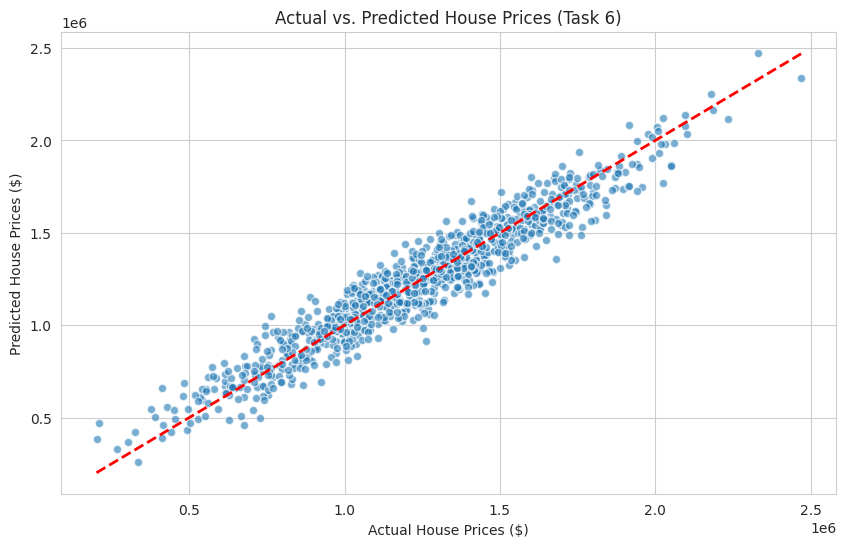

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
sns.set_style('whitegrid')

# 2. Create the Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, edgecolors='white', alpha=0.6)

# 3. Add a diagonal "Perfect Prediction" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

# 4. Add Labels and Title
plt.xlabel('Actual House Prices ($)')
plt.ylabel('Predicted House Prices ($)')
plt.title('Actual vs. Predicted House Prices (Task 6)')

# 5. Show the plot
plt.show()